In [1]:
import os
import sys
dir_path = "/qumulo/shared_data/aofei_summer/RegTok/RegLLM"
sys.path.insert(0, dir_path)
os.environ['CUDA_VISIBLE_DEVICES'] = "2"
os.environ["HF_HUB_CACHE"]="/qumulo/shared_data/aofei_summer/LLMs"
from llava.eval.cli_v1 import RegLLMChatbot

/qumulo/shared_data/aofei_summer/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/qumulo/shared_data/aofei_summer/miniconda3/lib/python3.13/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
model_dir = "/qumulo/shared_data/aofei_summer/intern_records/LVLM/checkpoints/reg_seg_instruct_01"
model_args = {
        "model_name_or_path": "Qwen/Qwen3-8B",
        "pretrained_llm_path": model_dir,
        "regtok_config_path": "/qumulo/shared_data/aofei_summer/RegTok/source/tokenizer/regtok_config.yaml",
        "regtok_weight_path": "/qumulo/shared_data/aofei_summer/intern_records/RegTok/checkpoints/RegTok_pipeline_full_wo_quant/002-RegTok/checkpoints/0079280.pt",
        "use_regtok": True,
        "mm_vision_vq_type": "RegTok",
        "use_region_tokens": False,
        "vision_tower": "/qumulo/shared_data/aofei_summer/CLIPs/unimed_clip_vit_l14.pt",
        "mm_use_im_start_end": False,
        "mm_use_im_patch_token": True,
        "mm_vision_select_feature": "patch",
        "mm_patch_merge_type": "flat",
        "mm_projector_type": "mlp2x_gelu",
        "pretrain_mm_mlp_adapter": None,
        "mm_vision_select_layer": -1,
        "use_region_tokens": True,
        "use_sep_proj": False,
        "output_segmentation": True,
        "modality_num": 18,
        "codebook_size": 32
    }

In [3]:
bot = RegLLMChatbot(model_dir, model_args=model_args, device="cuda")

loading model from /qumulo/shared_data/aofei_summer/intern_records/LVLM/checkpoints/reg_seg_instruct_01
use RegSegForCausalLM!
576 codebook_token_ids


Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 38.07it/s]
Some weights of the model checkpoint at /qumulo/shared_data/aofei_summer/intern_records/LVLM/checkpoints/reg_seg_instruct_01 were not used when initializing RegSegForCausalLM: ['model.vision_tower.vision_tower.image_encoder.class_embedding', 'model.vision_tower.vision_tower.image_encoder.conv1.weight', 'model.vision_tower.vision_tower.image_encoder.ln_post.bias', 'model.vision_tower.vision_tower.image_encoder.ln_post.weight', 'model.vision_tower.vision_tower.image_encoder.ln_pre.bias', 'model.vision_tower.vision_tower.image_encoder.ln_pre.weight', 'model.vision_tower.vision_tower.image_encoder.positional_embedding', 'model.vision_tower.vision_tower.image_encoder.proj', 'model.vision_tower.vision_tower.image_encoder.transformer.resblocks.0.attn.in_proj_bias', 'model.vision_tower.vision_tower.image_encoder.transformer.resblocks.0.attn.in_proj_weight', 'model.vision_tower.vision_tower.image_encoder.transformer.resblo

load vision tower!
Number of stacks: 1
Upsample mode: conv
tokenflow load from: /qumulo/shared_data/aofei_summer/intern_records/RegTok/checkpoints/RegTok_pipeline_full_wo_quant/002-RegTok/checkpoints/0079280.pt
tokenflow model load success!!
pre loading complete!
Loading segmentation weights from /qumulo/shared_data/aofei_summer/intern_records/LVLM/checkpoints/reg_seg_instruct_01


In [4]:
# bot = RegLLMChatbot(model_dir, model_args=model_args, device="cuda")

In [5]:
ans, logits = bot.inference("What modality is used to take this image?", images="/qumulo/shared_data/aofei_summer/data/evaluation/imgs/xmlab102/source.jpg", output_seg=True)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


AttributeError: 'tuple' object has no attribute 'shape'

In [17]:
import torch

import matplotlib.pyplot as plt

output_seg = True

images="/qumulo/shared_data/aofei_summer/data/evaluation/imgs/xmlab102/source.jpg"
text = "Please segment all the organs."

def segment_image(images, text):
    if images is None:
        images = []

    if isinstance(images,str):
        images = [images]

    valid_images = []
    for img in images:
        # try:
        # if isinstance(img, str):
        #     Image.open(img).convert('RGB') # make sure that the path exists
        valid_images.append(img)
        # except:
        #     print(f'{img} This image is wrong.')
        #     continue
    images = valid_images
    # text
    # sources = preprocess_multimodal(
    #         copy.deepcopy([e["conversations"] for e in sources]),
    #         self.data_args)
    text = bot.input_moderation(text)
    text = bot.insert_image_placeholder(text, len(images) if None not in images else 0)

    conv = bot.get_conv_without_history(text)
    input_ids = bot.preprocess_qwen([conv], tokenizer=bot.tokenizer, has_image=True).to(bot.device)
    # print(input_ids, "input_idss")
    if len(images) > 0:
        list_image_tensors = bot.get_image_tensors(images)
        image_tensors = torch.stack(list_image_tensors).to(dtype=torch.bfloat16).to(bot.device)
    else:
        image_tensors = None

    with torch.inference_mode():
        # print(input_ids, image_tensors.size(), "input")
        if output_seg:
            outputs = bot.model.generate(
                input_ids,
                images=image_tensors.to(torch.bfloat16),
                use_cache=True,
                output_hidden_states=True,
                return_dict_in_generate=True,
                **bot.gen_kwargs)
            # outputs = self.model.evaluate(input_ids=input_ids, images=image_tensors)
            output_id = outputs.sequences

            final_layer_token_states = [step[-1] for step in outputs.hidden_states]
            final_layer_token_states[0] = final_layer_token_states[0][:, -1, :].unsqueeze(1)
            final_layer_token_states = torch.stack(final_layer_token_states, dim=1).squeeze(-2)

            print(final_layer_token_states.shape)
            seg_embeddings = bot.model.model.collect_seg_token_embeddings(final_layer_token_states, output_id)
            region_codes = bot.model.model.token_projection(
                seg_embeddings.view(-1, seg_embeddings.size(-1))
            ).view(seg_embeddings.shape[0], seg_embeddings.shape[1], -1)
            image_features = bot.model.model.extract_multi_visual_features(image_tensors.to(torch.bfloat16).to(final_layer_token_states.dtype))
            seg_logits, class_logits = bot.model.model.decode_masks(region_codes, image_features)

            answers = []
            for output_id in output_id:
                answers.append(bot.tokenizer.decode(output_id, skip_special_tokens=True).strip())
    return answers, seg_logits

torch.Size([1, 59, 4096])
['assistant\nThe only annotated organ is the small tumor nodule [M5_29] at bbox [0.582, 0.369, 0.017, 0.017]; it should be segmented as a focal lesion in this CT slice.']


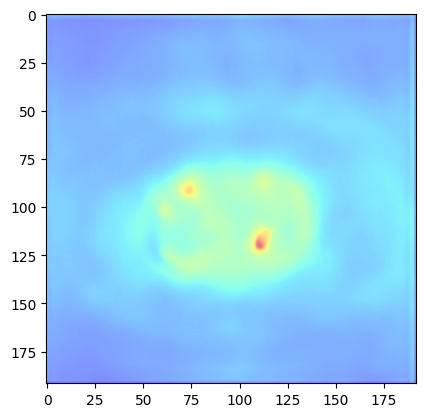

In [ ]:
images="/qumulo/shared_data/aofei_summer/data/evaluation/imgs/xmlab102/source.jpg"
text = "Please segment all the organs."

answers, seg_logits = segment_image(images, text)
print(answers)
# visualize the mask logits
plt.imshow(seg_logits[0][0].float().detach().cpu().numpy(), alpha=0.5, cmap='jet')

torch.Size([1, 56, 4096])
['assistant\nThe annotated region is the pulmonary organ (lung) [M4_21], with bbox [0.164, 0.203, 0.718, 0.62]; this mask covers both lungs on the radiograph.']


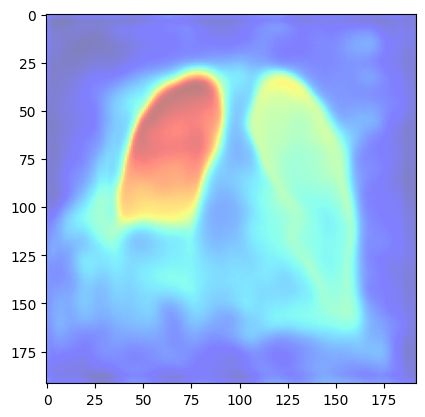

In [21]:
images="/qumulo/shared_data/aofei_summer/data/evaluation/imgs/xmlab129/source.jpg"
# text = "Identify the abnormality in the image."
text = "Please segment all the organs."

answers, seg_logits = segment_image(images, text)
print(answers)
# visualize the mask logits
plt.imshow(seg_logits[0][0].float().detach().cpu().numpy(), alpha=0.5, cmap='jet')

torch.Size([1, 61, 4096])
['assistant\nThe kidney is segmented as [M0_21] at bbox [0.568, 0.246, 0.138, 0.472]; it occupies the right lateral portion of the image and spans a tall vertical region consistent with renal anatomy.']


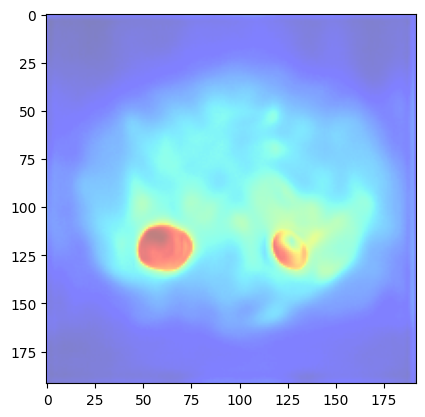

In [23]:
images="/qumulo/shared_data/aofei_summer/data/evaluation/imgs/xmlab214/source.jpg"
# text = "Identify the abnormality in the image."
text = "Please segment the kidney."

answers, seg_logits = segment_image(images, text)
print(answers)
# visualize the mask logits
plt.imshow(seg_logits[0][0].float().detach().cpu().numpy(), alpha=0.5, cmap='jet')

In [28]:
seg_logits.size()

torch.Size([1, 2, 192, 192])

torch.Size([1, 97, 4096])
['assistant\nThe liver is segmented as [M0_16] at bbox [0.275, 0.193, 0.468, 0.579]; within this organ there is a focal neoplasm labeled [M0_25] at bbox [0.369, 0.564, 0.237, 0.181], located in the lower-central portion of the liver on this slice.']


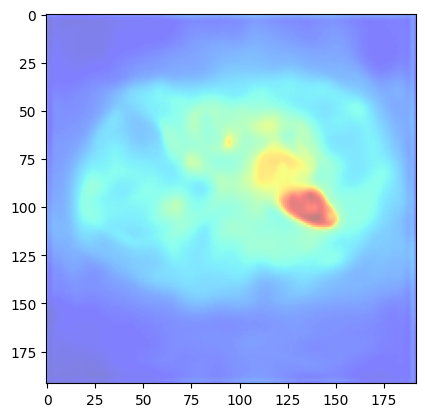

In [34]:
images="/qumulo/shared_data/aofei_summer/data/evaluation/imgs/xmlab274/source.jpg"
# text = "Identify the abnormality in the image."
text = "Please segment the liver and identify possibel abnormality."

answers, seg_logits = segment_image(images, text)
print(answers)
# visualize the mask logits
plt.imshow(seg_logits[0][0].float().detach().cpu().numpy(), alpha=0.5, cmap='jet')

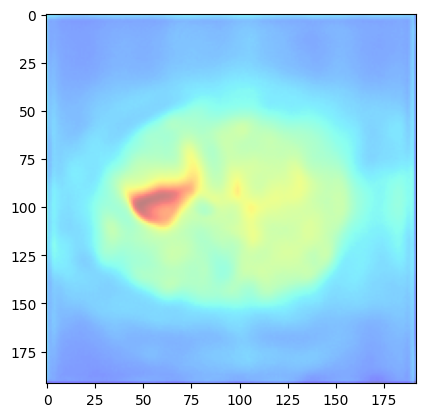

In [31]:
plt.imshow(seg_logits[0][1].float().detach().cpu().numpy(), alpha=0.5, cmap='jet')